In [1]:
from google.colab import files
uploaded = files.upload()

Saving Repayment - Repayment History.csv to Repayment - Repayment History.csv
Saving Loan_Application - Loan Applications.csv to Loan_Application - Loan Applications.csv
Saving CustomersCredit.xlsx - Customers.csv to CustomersCredit.xlsx - Customers.csv
Saving Credit Score  - Credit Bureau Reports.csv to Credit Score  - Credit Bureau Reports.csv


In [2]:
import pandas as pd
df_customers = pd.read_csv('CustomersCredit.xlsx - Customers.csv')
df_credit = pd.read_csv('Credit Score  - Credit Bureau Reports.csv')
df_loan = pd.read_csv('Loan_Application - Loan Applications.csv')
df_repayment = pd.read_csv('Repayment - Repayment History.csv')

In [3]:
print(df_customers.shape)
print(df_customers.duplicated().sum())
print(df_customers.isnull().sum())
print(df_customers.dtypes)

(1000, 9)
0
customer_id              0
first_name               0
last_name                0
age                      0
employment_length_yrs    0
housing_status           0
annual_income            0
employment_sector        0
created_at               0
dtype: int64
customer_id               object
first_name                object
last_name                 object
age                        int64
employment_length_yrs    float64
housing_status            object
annual_income             object
employment_sector         object
created_at                object
dtype: object


In [4]:
df_customers['full_name'] = df_customers['first_name'] + ' ' + df_customers['last_name']
del df_customers['first_name']
del df_customers['last_name']

In [5]:
df_customers['annual_income'] = df_customers['annual_income'].astype('str')
df_customers['annual_income'] = df_customers['annual_income'].str.replace('$', '')
df_customers['annual_income'] = df_customers['annual_income'].str.replace(',', '')
df_customers['annual_income'] = df_customers['annual_income'].astype('float64')

In [6]:
df_customers['employment_sector'].unique()

array(['Healthcare', 'Education', 'Finance', 'Services', 'Public Sector',
       'Manufacturing', 'Retail', 'Technology'], dtype=object)

In [7]:
df_customers['employment_sector'] = df_customers['employment_sector'].str.upper()

In [8]:
df_customers['created_at'] = pd.to_datetime(df_customers['created_at'])
df_customers['year'] = df_customers['created_at'].dt.year
df_customers['month'] = df_customers['created_at'].dt.month
df_customers['day'] = df_customers['created_at'].dt.day

In [9]:
df_customers['full_name'] = df_customers['full_name'].str.upper()

In [10]:
df_credit.head()

,report_id,customer_id,fico_score,cb_person_default_on_file,total_open_credit_lines,revolving_utilization_pct,derogatory_public_records,past_due_30_59_days_count,past_due_60_89_days_count,past_due_90_plus_days_count,report_date
0,CBR-000001,CUST-000001,695,N,6,36.32,0,0,0,0,2023-04-05
1,CBR-000002,CUST-000002,700,N,13,51.91,0,0,0,0,2022-11-18
2,CBR-000003,CUST-000003,607,N,12,34.58,0,0,0,0,2022-05-09
3,CBR-000004,CUST-000004,612,N,7,32.36,0,0,0,0,2022-12-21
4,CBR-000005,CUST-000005,621,N,9,12.03,0,0,0,0,2022-11-11


In [11]:
print(df_credit.shape)
print(df_credit.duplicated().sum())
print(df_credit.isnull().sum())
print(df_credit.dtypes)

(1000, 11)
0
report_id                      0
customer_id                    0
fico_score                     0
cb_person_default_on_file      0
total_open_credit_lines        0
revolving_utilization_pct      0
derogatory_public_records      0
past_due_30_59_days_count      0
past_due_60_89_days_count      0
past_due_90_plus_days_count    0
report_date                    0
dtype: int64
report_id                       object
customer_id                     object
fico_score                       int64
cb_person_default_on_file       object
total_open_credit_lines          int64
revolving_utilization_pct      float64
derogatory_public_records        int64
past_due_30_59_days_count        int64
past_due_60_89_days_count        int64
past_due_90_plus_days_count      int64
report_date                     object
dtype: object


In [12]:
df_credit['report_date'] = pd.to_datetime(df_credit['report_date'])

In [13]:
df_credit['year_credit'] = df_credit['report_date'].dt.year
df_credit['month_credit'] = df_credit['report_date'].dt.month
df_credit['day_credit'] = df_credit['report_date'].dt.day

In [14]:
df_credit['cb_person_default_on_file'].unique()

array(['N', 'Y'], dtype=object)

In [15]:
df_loan.head()

,loan_id,customer_id,loan_amount,loan_intent,interest_rate,loan_term_months,grade,dti_ratio,loan_status,application_date
0,LOAN-000001,CUST-000001,"$7,030.62",EDUCATION,12.36,24,C,0.3649,Late (16-30 days),2023-01-02
1,LOAN-000002,CUST-000002,"$26,682.36",EDUCATION,12.30,60,C,0.2606,Current,2022-11-07
2,LOAN-000003,CUST-000003,"$3,573.76",HOMEIMPROVEMENT,12.99,36,C,0.1688,Late (16-30 days),2022-03-29
3,LOAN-000004,CUST-000004,"$6,282.03",HOMEIMPROVEMENT,13.61,12,C,0.3308,Fully Paid,2023-02-14
4,LOAN-000005,CUST-000005,"$3,245.50",DEBTCONSOLIDATION,12.35,36,C,0.1310,Fully Paid,2022-11-17


In [16]:
print(df_loan.shape)
print(df_loan.duplicated().sum())
print(df_loan.isnull().sum())
print(df_loan.dtypes)

(1457, 10)
0
loan_id             0
customer_id         0
loan_amount         0
loan_intent         0
interest_rate       0
loan_term_months    0
grade               0
dti_ratio           0
loan_status         0
application_date    0
dtype: int64
loan_id              object
customer_id          object
loan_amount          object
loan_intent          object
interest_rate       float64
loan_term_months      int64
grade                object
dti_ratio           float64
loan_status          object
application_date     object
dtype: object


In [17]:
df_loan['loan_amount'] = df_loan['loan_amount'].astype('str')
df_loan['loan_amount'] = df_loan['loan_amount'].str.replace('$', '')
df_loan['loan_amount'] = df_loan['loan_amount'].str.replace(',', '')
df_loan['loan_amount'] = df_loan['loan_amount'].astype('float64')

In [18]:
df_loan['application_date'] = pd.to_datetime(df_loan['application_date'])
df_loan['year_loan'] = df_loan['application_date'].dt.year
df_loan['month_loan'] = df_loan['application_date'].dt.month
df_loan['day_loan'] = df_loan['application_date'].dt.day

In [19]:
df_loan['loan_intent'].unique()
df_loan['loan_intent'] = df_loan['loan_intent'].str.upper()
df_loan['loan_status'].unique()
df_loan['loan_status'] = df_loan['loan_status'].str.upper()

In [20]:
df_loan.head()

,loan_id,customer_id,loan_amount,loan_intent,interest_rate,loan_term_months,grade,dti_ratio,loan_status,application_date,year_loan,month_loan,day_loan
0,LOAN-000001,CUST-000001,7030.62,EDUCATION,12.36,24,C,0.3649,LATE (16-30 DAYS),2023-01-02,2023,1,2
1,LOAN-000002,CUST-000002,26682.36,EDUCATION,12.30,60,C,0.2606,CURRENT,2022-11-07,2022,11,7
2,LOAN-000003,CUST-000003,3573.76,HOMEIMPROVEMENT,12.99,36,C,0.1688,LATE (16-30 DAYS),2022-03-29,2022,3,29
3,LOAN-000004,CUST-000004,6282.03,HOMEIMPROVEMENT,13.61,12,C,0.3308,FULLY PAID,2023-02-14,2023,2,14
4,LOAN-000005,CUST-000005,3245.50,DEBTCONSOLIDATION,12.35,36,C,0.1310,FULLY PAID,2022-11-17,2022,11,17


In [21]:
df_loan['loan_intent'].unique()

array(['EDUCATION', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION', 'PERSONAL',
       'MEDICAL', 'VENTURE'], dtype=object)

In [22]:
df_loan['loan_status'].unique()

array(['LATE (16-30 DAYS)', 'CURRENT', 'FULLY PAID', 'LATE (31-120 DAYS)',
       'CHARGED OFF / DEFAULT'], dtype=object)

In [23]:
df_repayment.head()

,loan_id,payment_number,scheduled_payment_date,actual_payment_date,amount_due,amount_paid,days_late,payment_status
0,LOAN-000001,1,2023-02-02,2023-02-02,$329.15,$329.15,0,ON_TIME
1,LOAN-000001,2,2023-03-02,2023-03-26,$329.15,$329.15,24,LATE_1_30
2,LOAN-000001,3,2023-04-02,2023-04-01,$329.15,$329.15,0,ON_TIME
3,LOAN-000001,4,2023-05-02,2023-05-02,$329.15,$329.15,0,ON_TIME
4,LOAN-000001,5,2023-06-02,2023-06-02,$329.15,$329.15,0,ON_TIME


In [24]:
print(df_repayment.duplicated().sum())

0


In [25]:
print(df_repayment.isnull().sum())

loan_id                     0
payment_number              0
scheduled_payment_date      0
actual_payment_date       480
amount_due                  0
amount_paid                 0
days_late                   0
payment_status              0
dtype: int64


In [26]:
print(df_repayment.dtypes)

loan_id                   object
payment_number             int64
scheduled_payment_date    object
actual_payment_date       object
amount_due                object
amount_paid               object
days_late                  int64
payment_status            object
dtype: object


In [27]:
df_repayment['amount_due'] = df_repayment['amount_due'].astype('str')
df_repayment['amount_due'] = df_repayment['amount_due'].str.replace('$', '')
df_repayment['amount_due'] = df_repayment['amount_due'].str.replace(',', '')
df_repayment['amount_due'] = df_repayment['amount_due'].astype('float64')
df_repayment['amount_paid'] = df_repayment['amount_paid'].astype('str')
df_repayment['amount_paid'] = df_repayment['amount_paid'].str.replace('$', '')
df_repayment['amount_paid'] = df_repayment['amount_paid'].str.replace(',', '')
df_repayment['amount_paid'] = df_repayment['amount_paid'].astype('float64')

In [28]:
df_repayment['payment_status'].unique()

array(['ON_TIME', 'LATE_1_30', 'LATE_31_90', 'DEFAULTED'], dtype=object)

In [29]:
df_repayment.head()

,loan_id,payment_number,scheduled_payment_date,actual_payment_date,amount_due,amount_paid,days_late,payment_status
0,LOAN-000001,1,2023-02-02,2023-02-02,329.15,329.15,0,ON_TIME
1,LOAN-000001,2,2023-03-02,2023-03-26,329.15,329.15,24,LATE_1_30
2,LOAN-000001,3,2023-04-02,2023-04-01,329.15,329.15,0,ON_TIME
3,LOAN-000001,4,2023-05-02,2023-05-02,329.15,329.15,0,ON_TIME
4,LOAN-000001,5,2023-06-02,2023-06-02,329.15,329.15,0,ON_TIME


**What is the overall default rate across the loan portfolio?**

Default Rate = Defaulted Loans / Total Loans

In [30]:
total_number_default = df_repayment[df_repayment['payment_status'] == 'DEFAULTED'].groupby('loan_id').size().sum()
print(total_number_default)

480


In [31]:
total_loan_amount = df_loan['loan_amount'].size
print(total_loan_amount)

1457


In [32]:
default_rate = (total_number_default / total_loan_amount)*100
print(default_rate.round(7))

32.9444063


**Default Rate 32.944**



In [33]:
loan_stat = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT']
loan_amount_defaults = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT']['loan_amount']
print(loan_amount_defaults.size)

60


In [34]:
pd.crosstab(df_loan['loan_status'], df_loan['loan_intent'])

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
loan_status,,,,,,
CHARGED OFF / DEFAULT,8,8,10,14,7,13
CURRENT,76,80,70,75,92,98
FULLY PAID,111,120,89,120,114,110
LATE (16-30 DAYS),22,24,26,10,27,18
LATE (31-120 DAYS),25,14,28,12,15,21


### Defaulted Loans by Loan Amount Category

In [35]:
df_loan['loan_amount'].min()

2004.56

In [36]:
df_loan['loan_amount'].max()

39548.47

In [37]:
import pandas as pd

def count_default_in_category(loan_amount):
  if loan_amount < 2000:
    category = 'Null'
    return category
  elif loan_amount >= 2000 and loan_amount < 10000:
    category = '2000-9999'
    return category
  elif loan_amount >=10000 and loan_amount < 20000:
    category = '10000-19999'
    return category
  elif loan_amount >= 20000 and loan_amount < 30000:
    category = '20000-29999'
    return category
  elif loan_amount >= 30000 and loan_amount < 40000:
    category = '30000-39999'
    return category
  else:
    category = 'N/A'

In [38]:
df_loan['loan_amount_category'] = df_loan['loan_amount'].apply(count_default_in_category)
#Creating a new column in df_loan to categorise the loan amount

In [39]:
df_loan['loan_amount_category'].head()

,loan_amount_category
0,2000-9999
1,20000-29999
2,2000-9999
3,2000-9999
4,2000-9999


In [40]:
defaulted_loans_by_amount_category = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('loan_amount_category').size().reset_index(name='number_of_defaults')
display(defaulted_loans_by_amount_category)

,loan_amount_category,number_of_defaults
0,10000-19999,19
1,2000-9999,33
2,20000-29999,5
3,30000-39999,3


In [41]:
number_of_loan_category = df_loan.groupby('loan_amount_category').size().reset_index(name='number_of_loans')
display(number_of_loan_category)

,loan_amount_category,number_of_loans
0,10000-19999,473
1,2000-9999,769
2,20000-29999,167
3,30000-39999,48


In [42]:
default_rate_by_amount_category = pd.merge(defaulted_loans_by_amount_category, number_of_loan_category, on='loan_amount_category')
display(default_rate_by_amount_category)

,loan_amount_category,number_of_defaults,number_of_loans
0,10000-19999,19,473
1,2000-9999,33,769
2,20000-29999,5,167
3,30000-39999,3,48


In [43]:
rate_pc = (default_rate_by_amount_category['number_of_defaults'] / default_rate_by_amount_category['number_of_loans'])*100
pc_diff_baseline_loan_amount = (rate_pc - default_rate)
default_rate_by_amount_category['default_rate_pc'] = rate_pc
default_rate_by_amount_category['pc_diff_baseline_loan_amount'] = pc_diff_baseline_loan_amount

In [44]:
default_rate_by_amount_category.head()

,loan_amount_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_amount
0,10000-19999,19,473,4.016913,-28.927493
1,2000-9999,33,769,4.291287,-28.653119
2,20000-29999,5,167,2.994012,-29.950394
3,30000-39999,3,48,6.250000,-26.694406


Default Rate Loan Intent

In [45]:
default_loan_by_intent = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('loan_intent').size().reset_index(name='number_of_defaults')
display(default_loan_by_intent)

,loan_intent,number_of_defaults
0,DEBTCONSOLIDATION,8
1,EDUCATION,8
2,HOMEIMPROVEMENT,10
3,MEDICAL,14
4,PERSONAL,7
5,VENTURE,13


In [46]:
total_number_of_default_intent = df_loan.groupby('loan_intent').size().reset_index(name='number_of_loans')
display(total_number_of_default_intent)

,loan_intent,number_of_loans
0,DEBTCONSOLIDATION,242
1,EDUCATION,246
2,HOMEIMPROVEMENT,223
3,MEDICAL,231
4,PERSONAL,255
5,VENTURE,260


In [47]:
default_rate_by_intent = pd.merge(default_loan_by_intent, total_number_of_default_intent, on='loan_intent')
display(default_rate_by_intent)

,loan_intent,number_of_defaults,number_of_loans
0,DEBTCONSOLIDATION,8,242
1,EDUCATION,8,246
2,HOMEIMPROVEMENT,10,223
3,MEDICAL,14,231
4,PERSONAL,7,255
5,VENTURE,13,260


In [48]:
rate_pc_intent = (default_rate_by_intent['number_of_defaults'] / default_rate_by_intent['number_of_loans'])*100
pc_diff_baseline_loan_intent = (rate_pc_intent - default_rate)
default_rate_by_intent['default_rate_pc'] = rate_pc_intent
default_rate_by_intent['pc_diff_baseline_loan_intent'] = pc_diff_baseline_loan_intent
default_rate_by_intent.head()

,loan_intent,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_intent
0,DEBTCONSOLIDATION,8,242,3.305785,-29.638621
1,EDUCATION,8,246,3.252033,-29.692374
2,HOMEIMPROVEMENT,10,223,4.484305,-28.460101
3,MEDICAL,14,231,6.060606,-26.883800
4,PERSONAL,7,255,2.745098,-30.199308


Default Loan By Grade

In [49]:
default_loan_by_grade = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('grade').size().reset_index(name='number_of_defaults')
display(default_loan_by_grade)

,grade,number_of_defaults
0,C,7
1,D,38
2,E,15


In [50]:
default_number_of_loan_grade = df_loan.groupby('grade').size().reset_index(name='number_of_loans')
display(default_number_of_loan_grade)

,grade,number_of_loans
0,A,173
1,B,457
2,C,544
3,D,243
4,E,39
5,F,1


In [51]:
default_rate_by_grade = pd.merge(default_loan_by_grade, default_number_of_loan_grade, on='grade')
display(default_rate_by_grade)

,grade,number_of_defaults,number_of_loans
0,C,7,544
1,D,38,243
2,E,15,39


In [52]:
rate_pc_grade = (default_rate_by_grade['number_of_defaults']/default_rate_by_grade['number_of_loans'])*100
pc_diff_baseline_loan_grade = (rate_pc_grade - default_rate)
default_rate_by_grade['default_rate_pc'] = rate_pc_grade
default_rate_by_grade['pc_diff_baseline_loan_grade'] = pc_diff_baseline_loan_grade
default_rate_by_grade.head()

,grade,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_grade
0,C,7,544,1.286765,-31.657642
1,D,38,243,15.637860,-17.306546
2,E,15,39,38.461538,5.517132


Default Loan by Loan Term

In [53]:
df_loan['loan_term_months'].min()

12

In [54]:
df_loan['loan_term_months'].max()

60

In [55]:
import pandas as pd
def count_default_in_term(loan_term_months):
  if loan_term_months < 12:
    category = 'Null'
    return category
  elif loan_term_months >= 12 and loan_term_months < 24:
    category = '12-23'
    return category
  elif loan_term_months >= 24 and loan_term_months < 36:
    category = '24-35'
    return category
  elif loan_term_months >= 36 and loan_term_months < 48:
    category = '36-47'
    return category
  elif loan_term_months >= 48 and loan_term_months < 60:
    category = '48-59'
    return category
  else:
    category = 'N/A'

In [56]:
df_loan['loan_term_category'] = df_loan['loan_term_months'].apply(count_default_in_term)

In [57]:
default_loan_by_term = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('loan_term_category').size().reset_index(name='number_of_defaults')
display(default_loan_by_term)

,loan_term_category,number_of_defaults
0,12-23,11
1,24-35,16
2,36-47,9
3,48-59,13


In [58]:
default_number_of_loan_term = df_loan.groupby('loan_term_category').size().reset_index(name='number_of_loans')
display(default_number_of_loan_term)

,loan_term_category,number_of_loans
0,12-23,269
1,24-35,309
2,36-47,286
3,48-59,301


In [59]:
default_rate_by_term = pd.merge(default_loan_by_term, default_number_of_loan_term, on='loan_term_category')
display(default_rate_by_term)

,loan_term_category,number_of_defaults,number_of_loans
0,12-23,11,269
1,24-35,16,309
2,36-47,9,286
3,48-59,13,301


In [60]:
rate_pc_term = (default_rate_by_term['number_of_defaults'] / default_rate_by_term['number_of_loans'])*100
pc_diff_baseline_loan_term = (rate_pc_term - default_rate)
default_rate_by_term['default_rate_pc'] = rate_pc_term
default_rate_by_term['pc_diff_baseline_loan_term'] = pc_diff_baseline_loan_term
default_rate_by_term.head()

,loan_term_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_term
0,12-23,11,269,4.089219,-28.855187
1,24-35,16,309,5.177994,-27.766413
2,36-47,9,286,3.146853,-29.797553
3,48-59,13,301,4.318937,-28.625469


Default Rate by Loan Interest

In [61]:
df_loan['interest_rate'].min()

5.5

In [62]:
df_loan['interest_rate'].max()

21.7

In [63]:
import pandas as pd

def count_default_by_loan_interest (interest_rate):
  if interest_rate < 5:
    category = 'Null'
    return category
  elif interest_rate >= 5 and interest_rate < 10:
    category = '5-10'
    return category
  elif interest_rate >= 10 and interest_rate < 15:
    category = '10-15'
    return category
  elif interest_rate >= 15 and interest_rate < 20:
    category = '15-20'
    return category
  elif interest_rate >= 20 and interest_rate < 25:
    category = '20-25'
    return category
  else:
    category = 'N/A'

In [64]:
df_loan['interest_rate_category'] = df_loan['interest_rate'].apply(count_default_by_loan_interest)

In [65]:
default_rate_by_interest = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('interest_rate_category').size().reset_index(name='number_of_defaults')
display(default_rate_by_interest)

,interest_rate_category,number_of_defaults
0,10-15,17
1,15-20,42
2,20-25,1


In [66]:
number_of_interest_category = df_loan.groupby('interest_rate_category').size().reset_index(name='number_of_loans')
display(number_of_interest_category)

,interest_rate_category,number_of_loans
0,10-15,862
1,15-20,213
2,20-25,2
3,5-10,380


In [67]:
default_rate_by_interest = pd.merge(default_rate_by_interest, number_of_interest_category, on='interest_rate_category')
display(default_rate_by_interest)

,interest_rate_category,number_of_defaults,number_of_loans
0,10-15,17,862
1,15-20,42,213
2,20-25,1,2


In [68]:
rate_pc_interest = (default_rate_by_interest['number_of_defaults'] / default_rate_by_interest['number_of_loans'])*100
pc_diff_baseline_loan_interest = (rate_pc_interest - default_rate)
default_rate_by_interest['default_rate_pc'] = rate_pc_interest
default_rate_by_interest['pc_diff_baseline_loan_interest'] = pc_diff_baseline_loan_interest
default_rate_by_interest.head()

,interest_rate_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_interest
0,10-15,17,862,1.972158,-30.972249
1,15-20,42,213,19.718310,-13.226096
2,20-25,1,2,50.000000,17.055594


Default Reate by DTI

In [69]:
df_loan['dti_ratio'].head()
df_loan['dti_ratio'].min()
df_loan['dti_ratio'].max()

0.6728

In [70]:
import pandas as pd
def count_default_dti (dti_ratio):
  if dti_ratio < 0.06:
    category = 'Null'
    return category
  elif dti_ratio >= 0.06 and dti_ratio < 0.1:
    category = '0-1'
    return category
  elif dti_ratio >= 0.1 and dti_ratio < 0.2:
    category = '1-2'
    return category
  elif dti_ratio >= 0.2 and dti_ratio < 0.3:
    category = '2-3'
    return category
  elif dti_ratio >= 0.3 and dti_ratio < 0.4:
    category = '3-4'
    return category
  elif dti_ratio >= 0.4 and dti_ratio < 0.5:
    category = '4-5'
    return category
  elif dti_ratio >= 0.5 and dti_ratio < 0.6:
    category = '5-6'
    return category
  elif dti_ratio >= 0.6 and dti_ratio < 0.7:
    category = '6-7'
    return category
  else:
    return category

In [71]:
df_loan['default_dti_category'] = df_loan['dti_ratio'].apply(count_default_dti)

In [72]:
default_loan_by_dti = df_loan[df_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('default_dti_category').size().reset_index(name='number_of_defaults')
display(default_loan_by_dti)

,default_dti_category,number_of_defaults
0,1-2,17
1,2-3,23
2,3-4,12
3,4-5,6
4,5-6,1
5,6-7,1


In [73]:
number_of_default_dti_category = df_loan.groupby('default_dti_category').size().reset_index(name='number_of_loans')
display(number_of_default_dti_category)

,default_dti_category,number_of_loans
0,0-1,33
1,1-2,416
2,2-3,597
3,3-4,270
4,4-5,77
5,5-6,51
6,6-7,13


In [74]:
default_rate_by_dti = pd.merge(default_loan_by_dti, number_of_default_dti_category, on='default_dti_category')
display(default_rate_by_dti)

,default_dti_category,number_of_defaults,number_of_loans
0,1-2,17,416
1,2-3,23,597
2,3-4,12,270
3,4-5,6,77
4,5-6,1,51
5,6-7,1,13


In [75]:
rate_pc_dti = (default_rate_by_dti['number_of_defaults'] / default_rate_by_dti['number_of_loans'])*100
pc_diff_baseline_loan_dti = (rate_pc_dti - default_rate)
default_rate_by_dti['default_rate_pc'] = rate_pc_dti
default_rate_by_dti['pc_diff_baseline_loan_dti'] = pc_diff_baseline_loan_dti

In [76]:
default_rate_by_dti.head()

,default_dti_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_dti
0,1-2,17,416,4.086538,-28.857868
1,2-3,23,597,3.852596,-29.091810
2,3-4,12,270,4.444444,-28.499962
3,4-5,6,77,7.792208,-25.152199
4,5-6,1,51,1.960784,-30.983622


Default Rate By Age

In [77]:
customer_loan = pd.merge(df_customers, df_loan, on='customer_id')

In [78]:
def count_default_by_age (age):
  if age < 18:
    category = "Too Young"
    return category
  elif age >= 18 and age < 25:
    category = "18-24"
    return category
  elif age >= 25 and age < 35:
    category = "25-34"
    return category
  elif age >= 35 and age < 45:
    category = "35-44"
    return category
  elif age >= 45 and age < 55:
    category = "45-54"
    return category
  elif age >= 55 and age < 65:
    category = "55-65"
    return category
  elif age >= 65 and age <= 70:
    category = "65-70"
    return category
  else:
    return category

In [79]:
customer_loan['default_age_category'] = customer_loan['age'].apply(count_default_by_age)

In [80]:
number_of_default_age_category = customer_loan[customer_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('default_age_category').size().reset_index(name='number_of_defaults')
display(number_of_default_age_category)

,default_age_category,number_of_defaults
0,18-24,11
1,25-34,7
2,35-44,15
3,45-54,10
4,55-65,12
5,65-70,5


In [81]:
number_of_loans_default_age_category = customer_loan.groupby('default_age_category').size().reset_index(name='number_of_loans')
display(number_of_loans_default_age_category)

,default_age_category,number_of_loans
0,18-24,180
1,25-34,279
2,35-44,308
3,45-54,287
4,55-65,252
5,65-70,151


In [82]:
default_rate_by_age_category = pd.merge(number_of_default_age_category, number_of_loans_default_age_category, on='default_age_category')
display(default_rate_by_age_category)

,default_age_category,number_of_defaults,number_of_loans
0,18-24,11,180
1,25-34,7,279
2,35-44,15,308
3,45-54,10,287
4,55-65,12,252
5,65-70,5,151


In [83]:
rate_pc_age = (default_rate_by_age_category['number_of_defaults'] / default_rate_by_age_category['number_of_loans'])*100
pc_diff_baseline_loan_age = (rate_pc_age - default_rate)
default_rate_by_age_category['default_rate_pc'] = rate_pc_age
default_rate_by_age_category['pc_diff_baseline_loan_age'] = pc_diff_baseline_loan_age
default_rate_by_age_category.head()

,default_age_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_age
0,18-24,11,180,6.111111,-26.833295
1,25-34,7,279,2.508961,-30.435446
2,35-44,15,308,4.870130,-28.074276
3,45-54,10,287,3.484321,-29.460086
4,55-65,12,252,4.761905,-28.182502


Default Rate by Emploment Sector

In [84]:
customer_loan['employment_sector'].unique()

array(['HEALTHCARE', 'EDUCATION', 'FINANCE', 'SERVICES', 'PUBLIC SECTOR',
       'MANUFACTURING', 'RETAIL', 'TECHNOLOGY'], dtype=object)

In [85]:
default_loan_by_employment = customer_loan[customer_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('employment_sector').size().reset_index(name='number_of_defaults')
display(default_loan_by_employment)

,employment_sector,number_of_defaults
0,EDUCATION,4
1,FINANCE,6
2,HEALTHCARE,5
3,MANUFACTURING,10
4,PUBLIC SECTOR,7
5,RETAIL,9
6,SERVICES,11
7,TECHNOLOGY,8


In [86]:
number_of_default_loan_employment = customer_loan.groupby('employment_sector').size().reset_index(name='number_of_loans')
display(number_of_default_loan_employment)

,employment_sector,number_of_loans
0,EDUCATION,159
1,FINANCE,169
2,HEALTHCARE,228
3,MANUFACTURING,199
4,PUBLIC SECTOR,180
5,RETAIL,170
6,SERVICES,171
7,TECHNOLOGY,181


In [87]:
default_rate_by_employment = pd.merge(default_loan_by_employment, number_of_default_loan_employment, on='employment_sector')
display(default_rate_by_employment)

,employment_sector,number_of_defaults,number_of_loans
0,EDUCATION,4,159
1,FINANCE,6,169
2,HEALTHCARE,5,228
3,MANUFACTURING,10,199
4,PUBLIC SECTOR,7,180
5,RETAIL,9,170
6,SERVICES,11,171
7,TECHNOLOGY,8,181


In [88]:
rate_pc_employment = (default_rate_by_employment['number_of_defaults'] / default_rate_by_employment['number_of_loans'])*100
pc_diff_baseline_loan_employment = (rate_pc_employment - default_rate)
default_rate_by_employment['default_rate_pc'] = rate_pc_employment
default_rate_by_employment['pc_diff_baseline_loan_employment'] = pc_diff_baseline_loan_employment

In [89]:
default_rate_by_employment

,employment_sector,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_employment
0,EDUCATION,4,159,2.515723,-30.428683
1,FINANCE,6,169,3.550296,-29.394110
2,HEALTHCARE,5,228,2.192982,-30.751424
3,MANUFACTURING,10,199,5.025126,-27.919281
4,PUBLIC SECTOR,7,180,3.888889,-29.055517
5,RETAIL,9,170,5.294118,-27.650289
6,SERVICES,11,171,6.432749,-26.511658
7,TECHNOLOGY,8,181,4.419890,-28.524517


Default Rate by Housing Status

In [90]:
df_customers['housing_status'].unique()

array(['MORTGAGE', 'RENT', 'OTHER', 'OWN'], dtype=object)

In [91]:
number_of_default_housing = customer_loan[customer_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('housing_status').size().reset_index(name='number_of_defaults')
display(number_of_default_housing)

,housing_status,number_of_defaults
0,MORTGAGE,24
1,OTHER,1
2,OWN,12
3,RENT,23


In [92]:
number_of_loans_default_housing = customer_loan.groupby('housing_status').size().reset_index(name='number_of_loans')
display(number_of_loans_default_housing)

,housing_status,number_of_loans
0,MORTGAGE,582
1,OTHER,62
2,OWN,234
3,RENT,579


In [93]:
default_rate_by_housing = pd.merge(number_of_default_housing, number_of_loans_default_housing, on='housing_status')

In [94]:
default_rate_by_housing

,housing_status,number_of_defaults,number_of_loans
0,MORTGAGE,24,582
1,OTHER,1,62
2,OWN,12,234
3,RENT,23,579


In [95]:
rate_pc_housing = (default_rate_by_housing['number_of_defaults'] / default_rate_by_housing['number_of_loans'])*100
pc_diff_baseline_loan_housing = (rate_pc_housing - default_rate)
default_rate_by_housing['pc_diff_baseline_loan_housing'] = pc_diff_baseline_loan_housing
default_rate_by_housing['default_rate_pc'] = rate_pc_housing
default_rate_by_housing

,housing_status,number_of_defaults,number_of_loans,pc_diff_baseline_loan_housing,default_rate_pc
0,MORTGAGE,24,582,-28.820695,4.123711
1,OTHER,1,62,-31.331503,1.612903
2,OWN,12,234,-27.816201,5.128205
3,RENT,23,579,-28.972040,3.972366


Default Rate by Employment Length

In [96]:
customer_loan['employment_length_yrs'].min()

0.0

In [97]:
customer_loan['employment_length_yrs'].max()

30.6

In [98]:
def count_default_by_employment_length (employment_length_yrs):
  if employment_length_yrs >= 0 and employment_length_yrs < 10:
    category = '0-9'
    return category
  elif employment_length_yrs >= 10 and employment_length_yrs <20:
    category = '10-19'
    return category
  elif employment_length_yrs >= 20 and employment_length_yrs < 30:
    category = '20-29'
    return category
  elif employment_length_yrs >= 30 and employment_length_yrs < 40:
    category = '30-39'
    return category
  else:
    category = 'N/A'

In [99]:
customer_loan['employment_length_category'] = customer_loan['employment_length_yrs'].apply(count_default_by_employment_length)

In [100]:
number_of_default_employment_age = customer_loan[customer_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('employment_length_category').size().reset_index(name='number_of_defaults')
display(number_of_default_employment_age)

,employment_length_category,number_of_defaults
0,0-9,51
1,10-19,9


In [101]:
number_of_loan_default_employment_age = customer_loan.groupby('employment_length_category').size().reset_index(name='number_of_loans')
display(number_of_loan_default_employment_age)

,employment_length_category,number_of_loans
0,0-9,1262
1,10-19,181
2,20-29,13
3,30-39,1


In [102]:
rate_pc_employment_age = (number_of_default_employment_age['number_of_defaults'] / number_of_loan_default_employment_age['number_of_loans'])*100
pc_diff_baseline_loan_employment_age = (rate_pc_employment_age - default_rate)
number_of_default_employment_age['pc_diff_baseline_loan_employment_age'] = pc_diff_baseline_loan_employment_age
number_of_default_employment_age['default_rate_pc'] = rate_pc_employment_age

In [103]:
number_of_default_employment_age

,employment_length_category,number_of_defaults,pc_diff_baseline_loan_employment_age,default_rate_pc
0,0-9,51,-28.903202,4.041204
1,10-19,9,-27.972031,4.972376


Annual Income Default

In [104]:
df_customers['annual_income'].min()

18000.0

In [105]:
df_customers['annual_income'].max()

183968.24

In [106]:
def count_default_by_annual_income (annual_income):
  if annual_income < 18000:
    category = 'Null'
    return category
  elif annual_income >= 18000 and annual_income < 36000:
    category = '18000-36000'
    return category
  elif annual_income >= 36000 and annual_income < 54000:
    category = '36000-54000'
    return category
  elif annual_income >= 54000 and annual_income < 72000:
    category = '54000-72000'
    return category
  elif annual_income >= 72000 and annual_income < 90000:
    category = '72000-90000'
    return category
  elif annual_income >= 90000 and annual_income < 108000:
    category = '90000-108000'
    return category
  elif annual_income >= 108000 and annual_income < 126000:
    category = '108000-126000'
    return category
  elif annual_income >= 126000 and annual_income < 144000:
    category = '126000-144000'
    return category
  elif annual_income >= 144000 and annual_income < 162000:
    category = '144000-162000'
    return category
  elif annual_income >= 162000 and annual_income < 180000:
    category = '162000-180000'
    return category
  elif annual_income >= 180000 and annual_income < 198000:
    category = '180000-198000'
    return category
  else:
      category = 'N/A'

In [107]:
customer_loan['annual_income_category'] = customer_loan['annual_income'].apply(count_default_by_annual_income)

In [108]:
default_rate_by_annual_income = customer_loan[customer_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('annual_income_category').size().reset_index(name='number_of_defaults')
display(default_rate_by_annual_income)

,annual_income_category,number_of_defaults
0,108000-126000,2
1,126000-144000,1
2,162000-180000,2
3,18000-36000,19
4,36000-54000,17
5,54000-72000,10
6,72000-90000,5
7,90000-108000,4


In [109]:
number_of_loan_default_annual_income = customer_loan.groupby('annual_income_category').size().reset_index(name='number_of_loans')
display(number_of_loan_default_annual_income)

,annual_income_category,number_of_loans
0,108000-126000,44
1,126000-144000,19
2,144000-162000,9
3,162000-180000,10
4,18000-36000,385
5,180000-198000,5
6,36000-54000,502
7,54000-72000,232
8,72000-90000,177
9,90000-108000,74


In [110]:
default_rate_by_annual_income = pd.merge(default_rate_by_annual_income, number_of_loan_default_annual_income, on='annual_income_category')
display(default_rate_by_annual_income)

,annual_income_category,number_of_defaults,number_of_loans
0,108000-126000,2,44
1,126000-144000,1,19
2,162000-180000,2,10
3,18000-36000,19,385
4,36000-54000,17,502
5,54000-72000,10,232
6,72000-90000,5,177
7,90000-108000,4,74


In [111]:
rate_pc_annual_income = (default_rate_by_annual_income['number_of_defaults'] / default_rate_by_annual_income['number_of_loans'])*100
pc_diff_baseline_loan_annual_income = (rate_pc_annual_income - default_rate)
default_rate_by_annual_income['default_rate_pc'] = rate_pc_annual_income
default_rate_by_annual_income['pc_diff_baseline_loan_annual_income'] = pc_diff_baseline_loan_annual_income

In [112]:
default_rate_by_annual_income

,annual_income_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_annual_income
0,108000-126000,2,44,4.545455,-28.398952
1,126000-144000,1,19,5.263158,-27.681248
2,162000-180000,2,10,20.000000,-12.944406
3,18000-36000,19,385,4.935065,-28.009341
4,36000-54000,17,502,3.386454,-29.557952
5,54000-72000,10,232,4.310345,-28.634061
6,72000-90000,5,177,2.824859,-30.119548
7,90000-108000,4,74,5.405405,-27.539001


Default Rate by Credit Score

In [113]:
def count_default_by_credit_score (fico_score):
  if fico_score < 300:
    category = 'Very Poor'
    return category
  elif fico_score >= 300 and fico_score <= 579:
    category = 'Poor'
    return category
  elif fico_score >= 580 and fico_score <= 669:
    category = 'Fair'
    return category
  elif fico_score >= 670 and fico_score <= 739:
    category = 'Good'
    return category
  elif fico_score >= 740 and fico_score <= 799:
    category = 'Very Good'
    return category
  elif fico_score >= 800 and fico_score <= 850:
    category = 'Excellent'
    return category
  else:
    category = 'Exceptional'

In [114]:
credit_loan = pd.merge(df_credit, df_loan, on='customer_id')

In [115]:
credit_loan['credit_score_category'] = credit_loan['fico_score'].apply(count_default_by_credit_score)

In [116]:
number_of_default_credit_score = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('credit_score_category').size().reset_index(name='number_of_defaults')
display(number_of_default_credit_score)

,credit_score_category,number_of_defaults
0,Poor,60


In [117]:
number_of_default_loan_credit_score = credit_loan.groupby('credit_score_category').size().reset_index(name='number_of_loans')
display(number_of_default_loan_credit_score)

,credit_score_category,number_of_loans
0,Excellent,45
1,Fair,541
2,Good,518
3,Poor,144
4,Very Good,209


In [118]:
default_rate_by_credit_score = pd.merge(number_of_default_credit_score, number_of_default_loan_credit_score, on='credit_score_category')
display(default_rate_by_credit_score)

,credit_score_category,number_of_defaults,number_of_loans
0,Poor,60,144


In [119]:
rate_pc_credit_score = (default_rate_by_credit_score['number_of_defaults'] / default_rate_by_credit_score['number_of_loans'])*100
pc_diff_baseline_loan_credit_score = (rate_pc_credit_score - default_rate)
default_rate_by_credit_score['default_rate_pc'] = rate_pc_credit_score
default_rate_by_credit_score['pc_diff_baseline_loan_credit_score'] = pc_diff_baseline_loan_credit_score

In [120]:
default_rate_by_credit_score

,credit_score_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_credit_score
0,Poor,60,144,41.666667,8.72226


Default Rate of Customers with Previous Credit Record

In [121]:
credit_loan['cb_person_default_on_file'].unique()

array(['N', 'Y'], dtype=object)

In [122]:
number_of_default_on_file = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('cb_person_default_on_file').size().reset_index(name='number_of_defaults')
display(number_of_default_on_file)

,cb_person_default_on_file,number_of_defaults
0,N,33
1,Y,27


In [123]:
number_of_loan_default_on_file = credit_loan.groupby('cb_person_default_on_file').size().reset_index(name='number_of_loans')
display(number_of_loan_default_on_file)

,cb_person_default_on_file,number_of_loans
0,N,1175
1,Y,282


In [124]:
default_rate_by_on_file = pd.merge(number_of_default_on_file, number_of_loan_default_on_file, on='cb_person_default_on_file')
display(default_rate_by_on_file)

,cb_person_default_on_file,number_of_defaults,number_of_loans
0,N,33,1175
1,Y,27,282


In [125]:
rate_pc_on_file = (default_rate_by_on_file['number_of_defaults'] / default_rate_by_on_file['number_of_loans'])*100
pc_diff_baseline_loan_on_file = (rate_pc_on_file - default_rate)
default_rate_by_on_file['default_rate_pc'] = rate_pc_on_file
default_rate_by_on_file['pc_diff_baseline_loan_on_file'] = pc_diff_baseline_loan_on_file

In [126]:
default_rate_by_on_file

,cb_person_default_on_file,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_on_file
0,N,33,1175,2.808511,-30.135896
1,Y,27,282,9.574468,-23.369938


Revolving Credit Utilization Default Rate

In [127]:
df_credit['revolving_utilization_pct'].min()

0.57

In [128]:
def count_default_by_revolving_utilization (revolving_utilization_pct):
  if revolving_utilization_pct < 0.1:
    category = 'Null'
    return category
  elif revolving_utilization_pct >= 0.1 and revolving_utilization_pct < 20.0:
    category = '0.1-20.0'
    return category
  elif revolving_utilization_pct >= 20.0 and revolving_utilization_pct < 40.0:
    category = '20.0-40.0'
    return category
  elif revolving_utilization_pct >= 40.0 and revolving_utilization_pct < 60.0:
    category = '40.0-60.0'
    return category
  elif revolving_utilization_pct >= 60.0 and revolving_utilization_pct < 80.0:
    category = '60.0-80.0'
    return category
  elif revolving_utilization_pct >= 80.0 and revolving_utilization_pct < 100.0:
    category = '80.0-100.0'
    return category
  else:
    category = 'N/A'

In [129]:
credit_loan['credit_utilization_category'] = credit_loan['revolving_utilization_pct'].apply(count_default_by_revolving_utilization)

In [130]:
number_of_defaults_by_credit_utilization = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('credit_utilization_category').size().reset_index(name='number_of_defaults')
display(number_of_defaults_by_credit_utilization)

,credit_utilization_category,number_of_defaults
0,0.1-20.0,11
1,20.0-40.0,30
2,40.0-60.0,13
3,60.0-80.0,6


In [131]:
from numpy import number
number_of_loans_by_credit_utilization = credit_loan.groupby('credit_utilization_category').size().reset_index(name='number_of_loans')
display(number_of_loans_by_credit_utilization)

,credit_utilization_category,number_of_loans
0,0.1-20.0,227
1,20.0-40.0,539
2,40.0-60.0,437
3,60.0-80.0,218
4,80.0-100.0,36


In [132]:
default_rate_by_credit_utilization = pd.merge(number_of_defaults_by_credit_utilization, number_of_loans_by_credit_utilization, on='credit_utilization_category')

In [133]:
rate_pc_credit_utilization = (default_rate_by_credit_utilization['number_of_defaults'] / default_rate_by_credit_utilization['number_of_loans'])*100
pc_diff_baseline_loan_credit_utilization = (rate_pc_credit_utilization - default_rate)
default_rate_by_credit_utilization['default_rate_pc'] = rate_pc_credit_utilization
default_rate_by_credit_utilization['pc_diff_baseline_loan_credit_utilization'] = pc_diff_baseline_loan_credit_utilization
default_rate_by_credit_utilization

,credit_utilization_category,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_credit_utilization
0,0.1-20.0,11,227,4.845815,-28.098591
1,20.0-40.0,30,539,5.565863,-27.378544
2,40.0-60.0,13,437,2.974828,-29.969578
3,60.0-80.0,6,218,2.752294,-30.192113


In [134]:
df_credit['derogatory_public_records'].unique()

array([0, 3, 1, 2])

In [135]:
df_credit['past_due_30_59_days_count'].unique()

array([0, 2, 1, 3])

In [136]:
df_credit['past_due_60_89_days_count'].unique()

array([0, 1, 2])

In [137]:
df_credit['past_due_90_plus_days_count'].unique()

array([0, 1])

Default Rate by Derogatory Public Records

In [138]:
number_of_default_by_derogatory_public_records = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('derogatory_public_records').size().reset_index(name='number_of_defaults')
display(number_of_default_by_derogatory_public_records)

,derogatory_public_records,number_of_defaults
0,0,48
1,1,10
2,2,1
3,3,1


In [139]:
number_of_loan_default_by_derogatory_public_records = credit_loan.groupby('derogatory_public_records').size().reset_index(name='number_of_loans')
display(number_of_loan_default_by_derogatory_public_records)

,derogatory_public_records,number_of_loans
0,0,1387
1,1,39
2,2,26
3,3,5


In [140]:
default_rate_by_derogatory_public_records = pd.merge(number_of_default_by_derogatory_public_records, number_of_loan_default_by_derogatory_public_records, on='derogatory_public_records')

In [141]:
rate_pc_derogatory_public_records = (default_rate_by_derogatory_public_records['number_of_defaults'] / default_rate_by_derogatory_public_records['number_of_loans'])*100
pc_diff_baseline_loan_derogatory_public_records = (rate_pc_derogatory_public_records - default_rate)
default_rate_by_derogatory_public_records['default_rate_pc'] = rate_pc_derogatory_public_records
default_rate_by_derogatory_public_records['pc_diff_baseline_loan_derogatory_public_records'] = pc_diff_baseline_loan_derogatory_public_records

In [142]:
default_rate_by_derogatory_public_records

,derogatory_public_records,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_derogatory_public_records
0,0,48,1387,3.460707,-29.483700
1,1,10,39,25.641026,-7.303381
2,2,1,26,3.846154,-29.098252
3,3,1,5,20.000000,-12.944406


Default by Past Due 30-59 Days

In [143]:
number_of_default_by_past_due_30_59_days = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('past_due_30_59_days_count').size().reset_index(name='number_of_defaults')
display(number_of_default_by_past_due_30_59_days)

,past_due_30_59_days_count,number_of_defaults
0,0,47
1,1,8
2,2,4
3,3,1


In [144]:
number_of_loan_default_by_past_due_30_59_days = credit_loan.groupby('past_due_30_59_days_count').size().reset_index(name='number_of_loans')
display(number_of_loan_default_by_past_due_30_59_days)

,past_due_30_59_days_count,number_of_loans
0,0,1237
1,1,138
2,2,57
3,3,25


In [145]:
default_rate_by_past_due_30_59_days = pd.merge(number_of_default_by_past_due_30_59_days, number_of_loan_default_by_past_due_30_59_days, on='past_due_30_59_days_count')

In [146]:
rate_pc_past_due_30_59_days = (default_rate_by_past_due_30_59_days['number_of_defaults'] / default_rate_by_past_due_30_59_days['number_of_loans'])*100
pc_diff_baseline_loan_past_due_30_59_days = (rate_pc_past_due_30_59_days - default_rate)
default_rate_by_past_due_30_59_days['default_rate_pc'] = rate_pc_past_due_30_59_days
default_rate_by_past_due_30_59_days['pc_diff_baseline_loan_past_due_30_59_days'] = pc_diff_baseline_loan_past_due_30_59_days

In [147]:
default_rate_by_past_due_30_59_days

,past_due_30_59_days_count,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_past_due_30_59_days
0,0,47,1237,3.799515,-29.144891
1,1,8,138,5.797101,-27.147305
2,2,4,57,7.017544,-25.926862
3,3,1,25,4.000000,-28.944406


Default Rate Past Due Credit in 60-89 Days Count

In [148]:
number_of_default_by_past_due_60_89_days = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('past_due_60_89_days_count').size().reset_index(name='number_of_defaults')
display(number_of_default_by_past_due_60_89_days)

,past_due_60_89_days_count,number_of_defaults
0,0,59
1,1,1


In [149]:
number_of_loan_default_by_past_due_60_89_days = credit_loan.groupby('past_due_60_89_days_count').size().reset_index(name='number_of_loans')
display(number_of_loan_default_by_past_due_60_89_days)

,past_due_60_89_days_count,number_of_loans
0,0,1420
1,1,34
2,2,3


In [150]:

default_rate_by_past_due_60_89_days = pd.merge(number_of_default_by_past_due_60_89_days, number_of_loan_default_by_past_due_60_89_days, on='past_due_60_89_days_count')

In [151]:
rate_pc_past_due_60_89_days = (default_rate_by_past_due_60_89_days['number_of_defaults'] / default_rate_by_past_due_60_89_days['number_of_loans'])*100
pc_diff_baseline_loan_past_due_60_89_days = (rate_pc_past_due_60_89_days - default_rate)
default_rate_by_past_due_60_89_days['default_rate_pc'] = rate_pc_past_due_60_89_days
default_rate_by_past_due_60_89_days['pc_diff_baseline_loan_past_due_60_89_days'] = pc_diff_baseline_loan_past_due_60_89_days

In [152]:
default_rate_by_past_due_60_89_days

,past_due_60_89_days_count,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_past_due_60_89_days
0,0,59,1420,4.154930,-28.789477
1,1,1,34,2.941176,-30.003230


Default Rate Past Due 90+ Days Count

In [153]:
number_of_default_by_past_due_90_plus_days = credit_loan[credit_loan['loan_status'] == 'CHARGED OFF / DEFAULT'].groupby('past_due_90_plus_days_count').size().reset_index(name='number_of_defaults')
display(number_of_default_by_past_due_90_plus_days)

,past_due_90_plus_days_count,number_of_defaults
0,0,60


In [154]:
number_pf_loan_default_by_past_due_90_plus_days = credit_loan.groupby('past_due_90_plus_days_count').size().reset_index(name='number_of_loans')
display(number_pf_loan_default_by_past_due_90_plus_days)

,past_due_90_plus_days_count,number_of_loans
0,0,1454
1,1,3


In [155]:
default_rate_by_past_due_90_plus_days = pd.merge(number_of_default_by_past_due_90_plus_days, number_pf_loan_default_by_past_due_90_plus_days, on='past_due_90_plus_days_count')

In [156]:
rate_pc_past_due_90_plus_days = (default_rate_by_past_due_90_plus_days['number_of_defaults'] / default_rate_by_past_due_90_plus_days['number_of_loans'])*100
pc_diff_baseline_loan_past_due_90_plus_days = (rate_pc_past_due_90_plus_days - default_rate)
default_rate_by_past_due_90_plus_days['default_rate_pc'] = rate_pc_past_due_90_plus_days
default_rate_by_past_due_90_plus_days['pc_diff_baseline_loan_past_due_90_plus_days'] = pc_diff_baseline_loan_past_due_90_plus_days

In [157]:
default_rate_by_past_due_90_plus_days

,past_due_90_plus_days_count,number_of_defaults,number_of_loans,default_rate_pc,pc_diff_baseline_loan_past_due_90_plus_days
0,0,60,1454,4.126547,-28.817859


In [158]:
# Identify loans that ever reached DEFAULTED status
defaulted_loans = (
    df_repayment.groupby('loan_id')['payment_status']
    .apply(lambda x: (x == 'DEFAULTED').any())
    .reset_index(name='eventually_defaulted')
)

defaulted_loans.head()

,loan_id,eventually_defaulted
0,LOAN-000001,False
1,LOAN-000002,False
2,LOAN-000003,False
3,LOAN-000004,False
4,LOAN-000005,False


In [159]:
# Get all unique loan IDs from df_repayment to serve as the base for our summary table
all_unique_loan_ids = df_repayment['loan_id'].unique()
df_summary = pd.DataFrame({'loan_id': all_unique_loan_ids})

# Merge the 'eventually_defaulted' status from the previously created defaulted_loans DataFrame
df_summary = pd.merge(df_summary, defaulted_loans, on='loan_id', how='left')
# Fill any potential NaN values in 'eventually_defaulted' with False (for loans not found in defaulted_loans)
df_summary['eventually_defaulted'] = df_summary['eventually_defaulted'].fillna(False)

# Calculate counts for each payment status for each loan_id
payment_status_counts = df_repayment.groupby(['loan_id', 'payment_status']).size().unstack(fill_value=0).reset_index()

# Select and rename the required count columns
payment_status_counts = payment_status_counts[['loan_id', 'ON_TIME', 'LATE_1_30', 'LATE_31_90']]
payment_status_counts = payment_status_counts.rename(columns={
    'ON_TIME': 'On_Time_Payment_Count',
    'LATE_1_30': '1-30_Days_Late_Count',
    'LATE_31_90': '30-90_Days_Late_Count'
})

# Merge these counts into the summary DataFrame
df_final_table = pd.merge(df_summary, payment_status_counts, on='loan_id', how='left')

# Fill any NaN values in count columns with 0 (for loans that never had a specific status)
df_final_table[['On_Time_Payment_Count', '1-30_Days_Late_Count', '30-90_Days_Late_Count']] = \
    df_final_table[['On_Time_Payment_Count', '1-30_Days_Late_Count', '30-90_Days_Late_Count']].fillna(0).astype(int)

# Display the first few rows of the final table
display(df_final_table.head())

,loan_id,eventually_defaulted,On_Time_Payment_Count,1-30_Days_Late_Count,30-90_Days_Late_Count
0,LOAN-000001,False,10,1,1
1,LOAN-000002,False,10,1,1
2,LOAN-000003,False,9,0,3
3,LOAN-000004,False,9,3,0
4,LOAN-000005,False,12,0,0


/tmp/ipykernel_2118/1186663465.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='eventually_defaulted', data=df_final_table, ax=axes[0], palette='viridis')
/tmp/ipykernel_2118/1186663465.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Defaulted', 'Eventually Defaulted'])
/tmp/ipykernel_2118/1186663465.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='eventually_defaulted', y='On_Time_Payment_Count', data=avg_on_time_payments, ax=axes[1], palette='plasma')
/tmp/ipykernel_2118/1186663465.py:20: UserWarning: set_ticklabels() should only be used with a fixed numbe

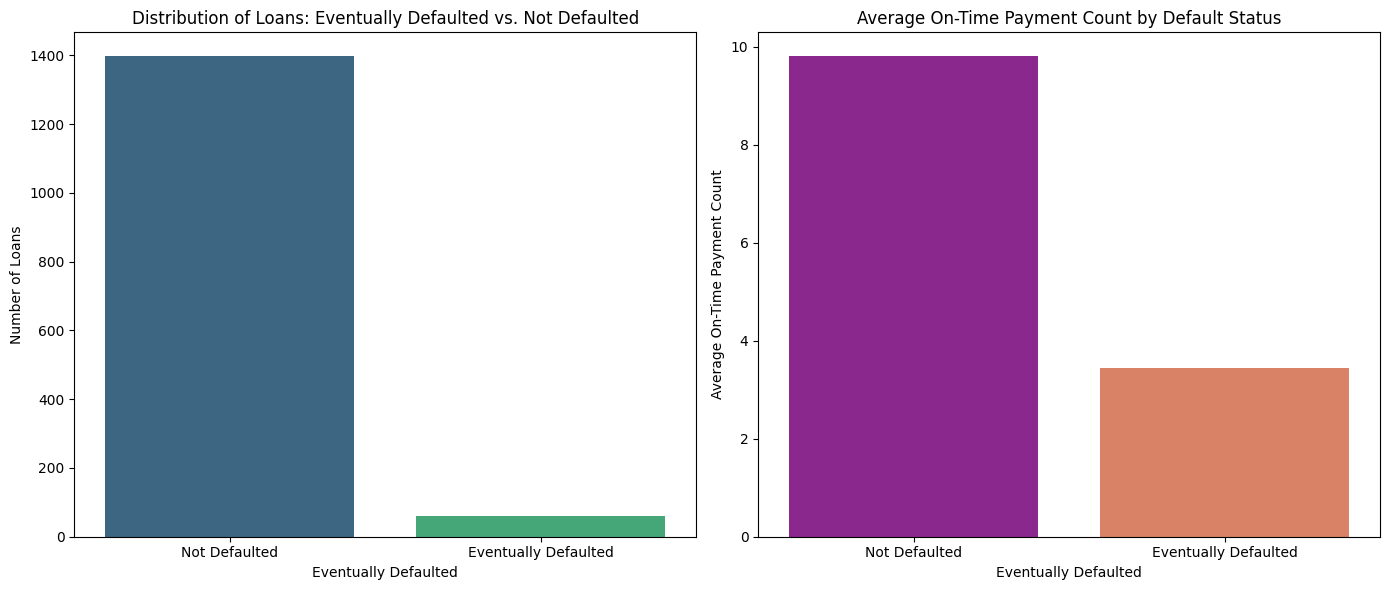

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Distribution of eventually_defaulted loans
sns.countplot(x='eventually_defaulted', data=df_final_table, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Loans: Eventually Defaulted vs. Not Defaulted')
axes[0].set_xlabel('Eventually Defaulted')
axes[0].set_ylabel('Number of Loans')
axes[0].set_xticklabels(['Not Defaulted', 'Eventually Defaulted'])

# Plot 2: Average On-Time Payment Count for defaulted vs. non-defaulted loans
avg_on_time_payments = df_final_table.groupby('eventually_defaulted')['On_Time_Payment_Count'].mean().reset_index()
sns.barplot(x='eventually_defaulted', y='On_Time_Payment_Count', data=avg_on_time_payments, ax=axes[1], palette='plasma')
axes[1].set_title('Average On-Time Payment Count by Default Status')
axes[1].set_xlabel('Eventually Defaulted')
axes[1].set_ylabel('Average On-Time Payment Count')
axes[1].set_xticklabels(['Not Defaulted', 'Eventually Defaulted'])

plt.tight_layout()
plt.show()

In [161]:
print(credit_loan.dtypes)

report_id                              object
customer_id                            object
fico_score                              int64
cb_person_default_on_file              object
total_open_credit_lines                 int64
revolving_utilization_pct             float64
derogatory_public_records               int64
past_due_30_59_days_count               int64
past_due_60_89_days_count               int64
past_due_90_plus_days_count             int64
report_date                    datetime64[ns]
year_credit                             int32
month_credit                            int32
day_credit                              int32
loan_id                                object
loan_amount                           float64
loan_intent                            object
interest_rate                         float64
loan_term_months                        int64
grade                                  object
dti_ratio                             float64
loan_status                       

Does a poor FICO score become even more concerning when combined with a poor Credit Grade?

In [162]:
fico_grade_analysis = (
    credit_loan
    .groupby(['credit_score_category', 'grade'])
    .agg(
        number_of_defaults=('loan_status', lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans=('loan_status', 'size')
    )
    .reset_index()
)

fico_grade_analysis['default_rate'] = (
    fico_grade_analysis['number_of_defaults'] /
    fico_grade_analysis['number_of_loans'] * 100
)

fico_grade_analysis['difference_from_baseline'] = (
    fico_grade_analysis['default_rate'] - 32.944
)

fico_grade_analysis

,credit_score_category,grade,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
0,Excellent,A,0,45,0.000000,-32.944000
1,Fair,B,0,61,0.000000,-32.944000
2,Fair,C,0,328,0.000000,-32.944000
3,Fair,D,0,146,0.000000,-32.944000
4,Fair,E,0,6,0.000000,-32.944000
5,Good,A,0,37,0.000000,-32.944000
6,Good,B,0,285,0.000000,-32.944000
7,Good,C,0,189,0.000000,-32.944000
8,Good,D,0,7,0.000000,-32.944000
9,Poor,C,7,20,35.000000,2.056000


Does poor grade looks more concerning when combined with dti category?

In [163]:
grade_status_analysis = (
    customer_loan
    .groupby(['grade', 'housing_status'])
    .agg(
        number_of_defaults=('loan_status', lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans=('loan_status', 'size')
    )
    .reset_index()
)

grade_status_analysis['default_rate'] = (
    grade_status_analysis['number_of_defaults'] /
    grade_status_analysis['number_of_loans'] * 100
)

grade_status_analysis['difference_from_baseline'] = (
    grade_status_analysis['default_rate'] - 32.944
)

grade_status_analysis = grade_status_analysis.sort_values(by='default_rate', ascending=False)
grade_status_analysis

,grade,housing_status,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
18,E,OWN,4,8,50.000000,17.056000
19,E,RENT,6,12,50.000000,17.056000
16,E,MORTGAGE,5,16,31.250000,-1.694000
14,D,OWN,7,36,19.444444,-13.499556
13,D,OTHER,1,6,16.666667,-16.277333
15,D,RENT,14,91,15.384615,-17.559385
12,D,MORTGAGE,16,110,14.545455,-18.398545
11,C,RENT,3,205,1.463415,-31.480585
8,C,MORTGAGE,3,224,1.339286,-31.604714
10,C,OWN,1,95,1.052632,-31.891368


Does Poor Credit Scored effect negetively the Housing Status?

In [164]:
import pandas as pd

temp_df = pd.merge(df_customers, df_credit, on='customer_id', how='inner')

temp_df = pd.merge(temp_df, df_loan, on='customer_id', how='inner')

temp_df['credit_score_category'] = temp_df['fico_score'].apply(count_default_by_credit_score)

fico_status_analysis = (
    temp_df
    .groupby(['credit_score_category', 'housing_status'])
    .agg(
        number_of_defaults=('loan_status', lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans=('loan_status', 'size')
        )
    .reset_index()
)

fico_status_analysis['default_rate'] = (
    fico_status_analysis['number_of_defaults'] /
    fico_status_analysis['number_of_loans'] * 100
)
fico_status_analysis['difference_from_baseline'] = (
    fico_status_analysis['default_rate'] - 32.944
)
fico_status_analysis = fico_status_analysis.sort_values(by='default_rate', ascending=False)
fico_status_analysis

,credit_score_category,housing_status,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
14,Poor,OWN,12,23,52.173913,19.229913
15,Poor,RENT,23,49,46.938776,13.994776
12,Poor,MORTGAGE,24,66,36.363636,3.419636
13,Poor,OTHER,1,6,16.666667,-16.277333
3,Excellent,RENT,0,17,0.000000,-32.944000
2,Excellent,OWN,0,9,0.000000,-32.944000
1,Excellent,OTHER,0,2,0.000000,-32.944000
0,Excellent,MORTGAGE,0,17,0.000000,-32.944000
4,Fair,MORTGAGE,0,233,0.000000,-32.944000
5,Fair,OTHER,0,20,0.000000,-32.944000


In [167]:
print(customer_loan.dtypes)

customer_id                           object
age                                    int64
employment_length_yrs                float64
housing_status                        object
annual_income                        float64
employment_sector                     object
created_at                    datetime64[ns]
full_name                             object
year                                   int32
month                                  int32
day                                    int32
loan_id                               object
loan_amount                          float64
loan_intent                           object
interest_rate                        float64
loan_term_months                       int64
grade                                 object
dti_ratio                            float64
loan_status                           object
application_date              datetime64[ns]
year_loan                              int32
month_loan                             int32
day_loan  

In [169]:
grade_employment_analysis = (
    customer_loan
    .groupby(['grade','employment_length_category'])
    .agg(
        number_of_defaults = ('loan_status',lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans = ('loan_status', 'size')
    )
    .reset_index()
)

grade_employment_analysis['default_rate'] = (
    grade_employment_analysis['number_of_defaults'] /
    grade_employment_analysis['number_of_loans'] * 100
)

grade_employment_analysis['difference_from_baseline'] = (
    grade_employment_analysis['default_rate'] - 32.944
)
grade_employment_analysis = grade_employment_analysis.sort_values(by='default_rate', ascending=False)
grade_employment_analysis

,grade,employment_length_category,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
13,E,10-19,3,6,50.000000,17.056000
12,E,0-9,12,33,36.363636,3.419636
11,D,10-19,6,27,22.222222,-10.721778
10,D,0-9,32,216,14.814815,-18.129185
7,C,0-9,7,462,1.515152,-31.428848
1,A,10-19,0,15,0.000000,-32.944000
0,A,0-9,0,157,0.000000,-32.944000
6,B,30-39,0,1,0.000000,-32.944000
5,B,20-29,0,4,0.000000,-32.944000
4,B,10-19,0,59,0.000000,-32.944000


In [175]:
credit_customer = pd.merge(credit_loan, customer_loan, on='customer_id')

In [182]:
credit_score_employment_analysis = (
    credit_customer
    .groupby(['credit_score_category', 'employment_length_category'])
    .agg(
        number_of_defaults = ('loan_status_y',lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans = ('loan_status_y', 'size')
    )
    .reset_index()
)
credit_score_employment_analysis['default_rate'] = (
    credit_score_employment_analysis['number_of_defaults'] /
    credit_score_employment_analysis['number_of_loans'] * 100
)
credit_score_employment_analysis['difference_from_baseline'] = (
    credit_score_employment_analysis['default_rate'] - 32.944
)
credit_score_employment_analysis = credit_score_employment_analysis.sort_values(by='default_rate', ascending=False)
credit_score_employment_analysis

,credit_score_category,employment_length_category,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
10,Poor,10-19,13,27,48.148148,15.204148
9,Poor,0-9,78,203,38.423645,5.479645
2,Fair,0-9,0,755,0.000000,-32.944000
1,Excellent,20-29,0,1,0.000000,-32.944000
0,Excellent,0-9,0,74,0.000000,-32.944000
4,Fair,20-29,0,10,0.000000,-32.944000
3,Fair,10-19,0,96,0.000000,-32.944000
5,Good,0-9,0,711,0.000000,-32.944000
6,Good,10-19,0,134,0.000000,-32.944000
8,Good,30-39,0,1,0.000000,-32.944000


In [183]:
print(credit_loan.dtypes)

report_id                              object
customer_id                            object
fico_score                              int64
cb_person_default_on_file              object
total_open_credit_lines                 int64
revolving_utilization_pct             float64
derogatory_public_records               int64
past_due_30_59_days_count               int64
past_due_60_89_days_count               int64
past_due_90_plus_days_count             int64
report_date                    datetime64[ns]
year_credit                             int32
month_credit                            int32
day_credit                              int32
loan_id                                object
loan_amount                           float64
loan_intent                            object
interest_rate                         float64
loan_term_months                        int64
grade                                  object
dti_ratio                             float64
loan_status                       

In [188]:
grade_fico_dti_analysis = (
    credit_loan
    .groupby(['grade', 'credit_score_category', 'default_dti_category'])
    .agg(number_of_defaults=('loan_status', lambda x: (x == 'CHARGED OFF / DEFAULT').sum()),
        number_of_loans=('loan_status', 'size')
    )
    .reset_index()
)

grade_fico_dti_analysis['default_rate'] = (
    grade_fico_dti_analysis['number_of_defaults'] /
    grade_fico_dti_analysis['number_of_loans'] * 100
)

grade_fico_dti_analysis['difference_from_baseline'] = (
    grade_fico_dti_analysis['default_rate'] - 32.944
)

grade_fico_dti_analysis = grade_fico_dti_analysis.sort_values(by='default_rate', ascending=False)
grade_fico_dti_analysis.head(20)

,grade,credit_score_category,default_dti_category,number_of_defaults,number_of_loans,default_rate,difference_from_baseline
56,C,Poor,6-7,1,1,100.000000,67.056000
77,D,Poor,5-6,1,1,100.000000,67.056000
86,E,Poor,4-5,1,1,100.000000,67.056000
76,D,Poor,4-5,4,4,100.000000,67.056000
53,C,Poor,3-4,2,3,66.666667,33.722667
85,E,Poor,3-4,3,5,60.000000,27.056000
54,C,Poor,4-5,1,2,50.000000,17.056000
84,E,Poor,2-3,6,13,46.153846,13.209846
83,E,Poor,1-2,5,12,41.666667,8.722667
74,D,Poor,2-3,15,36,41.666667,8.722667
